## 02 -- Sentiment Analysis (Twitter-RoBERTa)

Cilem tohoto notebooku je oskorovat kazdy relevantni Reddit post pomoci
sentiment modelu a agregovat vysledky na denni sentiment skore per ticker.

**Poznamka k volbe modelu:** Puvodne jsme zkouseli FinBERT (model trenovany
na financnich textech), ale rychly test na ukazkovych Reddit titulcich
odhalil zasadni problem -- FinBERT oznacoval i silne emocne vyhranene
vety ("to the moon", "lost my life savings") jako "neutral", protoze
neni trenovany na neformalnim/slangovem jazyce. Srovnani s modelem
trenovanym na social media textu (`cardiffnlp/twitter-roberta-base-sentiment-latest`)
ukazalo vyrazne presnejsi vysledky na stejnych vetach -- proto pouzivame
tenhle model misto FinBERT.

Tohle je zajimave metodologicke zjisteni samo o sobe: **vyber modelu
odpovidajiciho registru textu je stejne dulezity jako vyber spravne
architektury.** Financni sentiment model nemusi byt nejlepsi volba pro
financni diskuzi, pokud je psana neformalnim jazykem.

## Import knihoven

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from transformers import pipeline
import torch
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

posts_path = PROCESSED_DIR / "reddit_posts_tagged.csv"
assert posts_path.exists(), (
    f"{posts_path} neexistuje -- nejdriv spust notebook 01_data_cleaning "
    "(potrebujeme jeho posledni bunku, ktera uklada reddit_posts_tagged.csv)"
)

posts = pd.read_csv(posts_path)
posts["Date"] = pd.to_datetime(posts["Date"])
print(f"Nacteno {len(posts)} radku (post, ticker)")
posts.head()

Nacteno 185814 radku (post, ticker)


,id,Date,title,score,num_comments,Ticker
0,lkzz8c,2021-02-16,What's the future ? Will they ever coop large ...,1,0,AAPL
1,lkw2er,2021-02-16,Apple car,1,1,AAPL
2,lkvwy5,2021-02-16,Apple iCar,1,1,AAPL
3,lkvr83,2021-02-16,"M1 chip is fukt, $AAPL Puts?",1,0,AAPL
4,lkor1v,2021-02-15,"A Huge Fund Bought Tesla, Apple, and Microsoft...",1,0,AAPL


## Deduplikace pred scoringem

Jeden post muze byt otagovany vic tickery (napr. post zminujici "AAPL vs TSLA"
se objevi 2x v `posts` -- jednou pro kazdy ticker). FinBERT je vypocetne
narocny, takze nema smysl stejny text skorovat vickrat -- oskorujeme kazdy
**unikatni post** jen jednou a vysledek pak namapujeme zpet na vsechny jeho
(post, ticker) radky.

In [4]:
unique_posts = posts.drop_duplicates(subset="id")[["id", "title"]].reset_index(drop=True)
print(f"Unikatnich postu ke skorovani: {len(unique_posts)}")
print(f"(oproti {len(posts)} celkovych (post, ticker) radku)")

Unikatnich postu ke skorovani: 164590
(oproti 185814 celkovych (post, ticker) radku)


## Nacteni sentiment modelu

Pouzivame `cardiffnlp/twitter-roberta-base-sentiment-latest` -- RoBERTa
model dotrenovany na milionech tweetu, dobre zvlada neformalni jazyk,
slang a zkratky typicke pro social media (a tim padem i pro Reddit).
Model vraci pro kazdy text jednu ze 3 kategorii: `positive`, `negative`,
`neutral`, spolu s confidence skore.

In [5]:
device = 0 if torch.cuda.is_available() else -1
print(f"Pouzivam zarizeni: {'GPU' if device == 0 else 'CPU'}")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=128,
)

Pouzivam zarizeni: CPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Rychla kontrola na par ukazkovych titulcich

Toto srovnani jsme uz udelali samostatne (viz `compare_sentiment_models.py`
v `src/`) a potvrdilo, ze tenhle model zvlada Reddit-specificky jazyk
vyrazne lip nez FinBERT. Zopakujeme si to zde jako soucast notebooku,
at je cely postup reprodukovatelny na jednom miste.

In [6]:
sample_texts = [
    "GME to the moon! Diamond hands, never selling",
    "Lost my entire life savings on TSLA puts, guess I'll die",
    "AAPL reports Q3 earnings tomorrow, expecting inline results",
    "This stock is going to zero, sold everything",
    "Absolutely printing money on NVDA calls today",
]

for text, result in zip(sample_texts, sentiment_pipeline(sample_texts)):
    print(f"{result['label']:10s} ({result['score']:.3f})  {text}")

positive   (0.924)  GME to the moon! Diamond hands, never selling
negative   (0.921)  Lost my entire life savings on TSLA puts, guess I'll die
neutral    (0.825)  AAPL reports Q3 earnings tomorrow, expecting inline results
negative   (0.900)  This stock is going to zero, sold everything
positive   (0.488)  Absolutely printing money on NVDA calls today


Vysledky by mely odpovidat intuitivnimu smeru u vsech 5 vet -- pozitivni
euforie, ztrata penez jako negative, neutralni oznameni jako neutral,
"going to zero" jako negative a "printing money" jako positive. Pokud
tomu tak je, muzeme pokracovat na cely dataset.

## Batch inference s checkpointingem

Na CPU muze skorovani 100k+ textu trvat radove desitky minut az hodiny
v zavislosti na hardwaru. Zpracovavame po davkach (chunks) a prubezne
ukladame mezivysledky do docasneho souboru -- kdyby beh spadl nebo ho
prerusis, nezacinas od nuly, ale pokracujes tam, kde jsi skoncil.

**Pozor:** pokud jsi drive spustil tento notebook s FinBERT modelem,
smaz stary soubor `data/processed/_sentiment_checkpoint.csv` pred
spustenim nasledujicich bunek -- jinak by se namisto novych vysledku
pouzily ty stare, oskorovane spatnym modelem.

In [1]:
CHECKPOINT_PATH = PROCESSED_DIR / "_sentiment_checkpoint.csv"
BATCH_SIZE = 32
CHUNK_SIZE = 2000  # po kolika textech ukladame checkpoint

if CHECKPOINT_PATH.exists():
    done = pd.read_csv(CHECKPOINT_PATH)
    done_ids = set(done["id"])
    print(f"Nalezen checkpoint s {len(done)} jiz oskorovanymi posty, navazuji.")
else:
    done = pd.DataFrame(columns=["id", "label", "score"])
    done_ids = set()
    print("Zadny checkpoint, zacinam od zacatku.")

remaining = unique_posts[~unique_posts["id"].isin(done_ids)].reset_index(drop=True)
print(f"Zbyva oskorovat: {len(remaining)} postu")

NameError: name 'PROCESSED_DIR' is not defined

In [7]:
results = []

for start in tqdm(range(0, len(remaining), CHUNK_SIZE), desc="Chunks"):
    chunk = remaining.iloc[start : start + CHUNK_SIZE]
    texts = chunk["title"].astype(str).tolist()

    preds = sentiment_pipeline(texts, batch_size=BATCH_SIZE)

    for post_id, pred in zip(chunk["id"], preds):
        results.append({"id": post_id, "label": pred["label"], "score": pred["score"]})

    # Prubezne ukladani -- po kazdem chunku pripiseme k checkpointu
    chunk_df = pd.DataFrame(results[-len(chunk):])
    chunk_df.to_csv(
        CHECKPOINT_PATH,
        mode="a",
        header=not CHECKPOINT_PATH.exists(),
        index=False,
    )

print(f"Hotovo, oskorovano {len(results)} novych postu v tomto behu.")

Chunks:   0%|          | 0/83 [00:00<?, ?it/s]

Hotovo, oskorovano 164590 novych postu v tomto behu.


In [8]:
sentiment_scores = pd.read_csv(CHECKPOINT_PATH)
sentiment_scores = sentiment_scores.drop_duplicates(subset="id", keep="last")
print(f"Celkem oskorovanych unikatnich postu: {len(sentiment_scores)}")
sentiment_scores["label"].value_counts()

Celkem oskorovanych unikatnich postu: 164590


label
neutral     89962
positive    44649
negative    29979
Name: count, dtype: int64

## Prevod na signed sentiment skore

Pro dalsi analyzu je pohodlnejsi mit jedno ciselne skore na skale
-1 (velmi negativni) az +1 (velmi pozitivni) misto kategorie + confidence:

- `positive` -> `+score`
- `negative` -> `-score`
- `neutral`  -> `0` (neutralni nazor nema smer, jen ho potlacime na 0)

In [9]:
def to_signed(row):
    if row["label"] == "positive":
        return row["score"]
    elif row["label"] == "negative":
        return -row["score"]
    return 0.0

sentiment_scores["signed_sentiment"] = sentiment_scores.apply(to_signed, axis=1)
sentiment_scores.head()

,id,label,score,signed_sentiment
0,lkzz8c,neutral,0.791461,0.000000
1,lkw2er,positive,0.491282,0.491282
2,lkvwy5,neutral,0.682584,0.000000
3,lkvr83,negative,0.910706,-0.910706
4,lkor1v,neutral,0.582185,0.000000


## Namapovani zpet na (post, ticker) radky a denni agregace

Ted spojime sentiment skore zpet na puvodni `posts` tabulku (kde je pro
kazdy post i ticker a datum) a spocitame denni prumer per ticker.

In [10]:
posts_scored = posts.merge(
    sentiment_scores[["id", "label", "score", "signed_sentiment"]],
    on="id",
    how="left",
)

missing = posts_scored["signed_sentiment"].isna().sum()
print(f"Postu bez sentiment skore: {missing} (mely by byt 0, pokud checkpoint dobehl cely)")

posts_scored.head()

Postu bez sentiment skore: 0 (mely by byt 0, pokud checkpoint dobehl cely)


,id,Date,title,score_x,num_comments,Ticker,label,score_y,signed_sentiment
0,lkzz8c,2021-02-16,What's the future ? Will they ever coop large ...,1,0,AAPL,neutral,0.791461,0.000000
1,lkw2er,2021-02-16,Apple car,1,1,AAPL,positive,0.491282,0.491282
2,lkvwy5,2021-02-16,Apple iCar,1,1,AAPL,neutral,0.682584,0.000000
3,lkvr83,2021-02-16,"M1 chip is fukt, $AAPL Puts?",1,0,AAPL,negative,0.910706,-0.910706
4,lkor1v,2021-02-15,"A Huge Fund Bought Tesla, Apple, and Microsoft...",1,0,AAPL,neutral,0.582185,0.000000


In [11]:
daily_sentiment = (
    posts_scored
    .groupby(["Ticker", "Date"])
    .agg(
        post_count=("id", "count"),
        avg_sentiment=("signed_sentiment", "mean"),
        positive_count=("label", lambda x: (x == "positive").sum()),
        negative_count=("label", lambda x: (x == "negative").sum()),
        neutral_count=("label", lambda x: (x == "neutral").sum()),
    )
    .reset_index()
    .sort_values(["Ticker", "Date"])
)

daily_sentiment.head(10)

,Ticker,Date,post_count,avg_sentiment,positive_count,negative_count,neutral_count
0,AAPL,2020-01-02,7,0.329305,3,0,4
1,AAPL,2020-01-03,6,0.278295,2,0,4
2,AAPL,2020-01-04,2,-0.027872,1,1,0
3,AAPL,2020-01-05,1,0.000000,0,0,1
4,AAPL,2020-01-06,2,-0.369938,0,1,1
5,AAPL,2020-01-08,4,-0.066181,1,1,2
6,AAPL,2020-01-09,16,0.532786,10,0,6
7,AAPL,2020-01-10,6,0.196932,3,1,2
8,AAPL,2020-01-11,4,0.147247,1,0,3
9,AAPL,2020-01-12,4,0.426617,3,1,0


### Rychla vizualni kontrola

Podivame se na prubeh prumerneho sentimentu pro GME kolem obdobi
short squeeze (leden 2021) -- ocekavame extremni vykyvy.

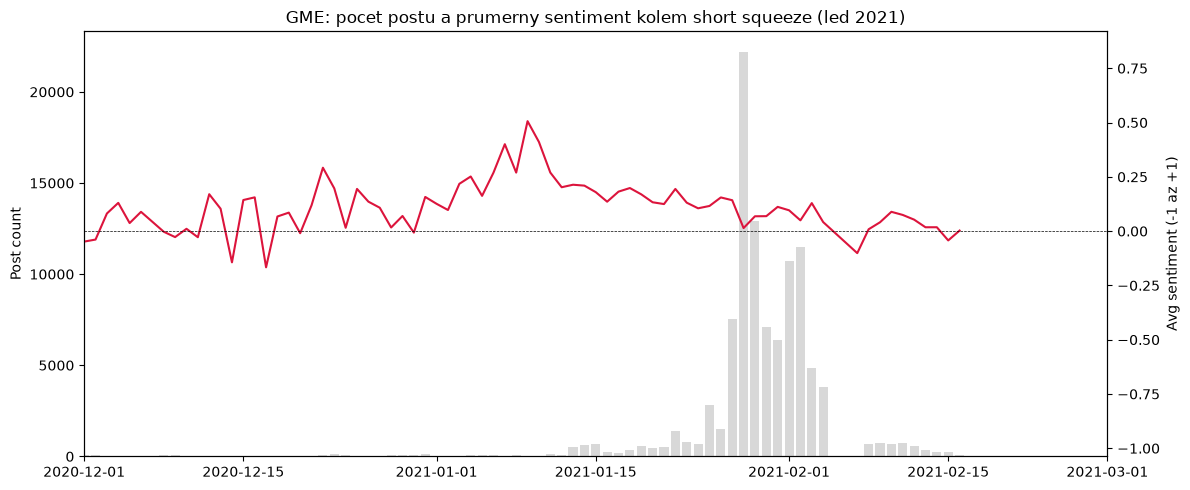

In [12]:
import matplotlib.pyplot as plt

gme = daily_sentiment[daily_sentiment["Ticker"] == "GME"].copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(gme["Date"], gme["post_count"], alpha=0.3, color="gray", label="Post count")
ax1.set_ylabel("Post count")

ax2 = ax1.twinx()
ax2.plot(gme["Date"], gme["avg_sentiment"], color="crimson", linewidth=1.5, label="Avg sentiment")
ax2.set_ylabel("Avg sentiment (-1 az +1)")
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")

ax1.set_xlim(pd.Timestamp("2020-12-01"), pd.Timestamp("2021-03-01"))
plt.title("GME: pocet postu a prumerny sentiment kolem short squeeze (led 2021)")
fig.tight_layout()
plt.show()

## Ulozeni

Ukladame denni sentiment per ticker -- tohle bude hlavni vstup pro
notebook 03, kde to spojime s cenovymi daty.

In [13]:
output_path = PROCESSED_DIR / "reddit_daily_sentiment.csv"
daily_sentiment.to_csv(output_path, index=False)
print(f"Ulozeno: {output_path} ({len(daily_sentiment)} radku)")

# Checkpoint uz nepotrebujeme, finalni vysledek mame ulozeny samostatne
# (necham ho zatim netknuty pro pripad, ze bys chtel pridat dalsi tickery
# a nechtel skorovat od znovu -- smaz rucne, az si bude jisty, ze uz ho
# nepotrebujes)

Ulozeno: /Users/maxkubicek/Desktop/market-pulse/data/processed/reddit_daily_sentiment.csv (2591 radku)


## Shrnuti

- Puvodne zvazovan FinBERT, ale rychly test odhalil, ze spatne zvlada
  Reddit slang -- prepnuto na `cardiffnlp/twitter-roberta-base-sentiment-latest`
- Vsechny relevantni posty oskorovany (label + confidence)
- Prevedeno na signed sentiment skore (-1 az +1)
- Agregovano na denni uroven per ticker (`reddit_daily_sentiment.csv`)
- GME kolem short squeeze ukazuje ocekavany vzorec -- prudky napor postu
  a vychyleny sentiment

**Dalsi krok (notebook 03):** spojeni `prices_clean.csv` a
`reddit_daily_sentiment.csv` do jedne casove osy. Tady musime velmi peclive
osetrit look-ahead bias -- sentiment za den X smi ovlivnovat jen obchodni
rozhodnuti pro den X+1 (nebo pozdeji), nikdy ne cenu, ktera uz v den X
nastala driv, nez byl sentiment znamy.